In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [6]:
df = pd.read_csv("ai_job_market.csv")

df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   job_id            2000 non-null   int64
 1   company_name      2000 non-null   str  
 2   industry          2000 non-null   str  
 3   job_title         2000 non-null   str  
 4   skills_required   2000 non-null   str  
 5   experience_level  2000 non-null   str  
 6   employment_type   2000 non-null   str  
 7   location          2000 non-null   str  
 8   salary_range_usd  2000 non-null   str  
 9   posted_date       2000 non-null   str  
 10  company_size      2000 non-null   str  
 11  tools_preferred   2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 481.7 KB


In [8]:
df.describe(include='all')

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
count,2000.000000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000
unique,NaN,1909,7,8,1985,3,4,2000,2000,680,3,352
top,NaN,Johnson LLC,Automotive,Data Analyst,"Flask, Scikit-learn, NumPy",Entry,Internship,"Tracybury, AR",92860-109598,2023-10-03,Startup,KDB+
freq,NaN,4,300,271,2,702,574,1,1,10,672,96
mean,1000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,577.494589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,500.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1000.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1500.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique())


job_id:
2000

company_name:
1909

industry:
7

job_title:
8

skills_required:
1985

experience_level:
3

employment_type:
4

location:
2000

salary_range_usd:
2000

posted_date:
680

company_size:
3

tools_preferred:
352


In [10]:
df = df.drop(columns=["job_id", "company_name", "location"])

In [11]:
df[['min_salary', 'max_salary']] = df['salary_range_usd'].str.split('-', expand=True)

df['min_salary'] = df['min_salary'].astype(float)
df['max_salary'] = df['max_salary'].astype(float)

df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2

df = df.drop(columns=['salary_range_usd'])

In [21]:
# Value Counts

for col in ['industry', 'experience_level', 'employment_type', 'company_size']:
    print(df[col].value_counts())

industry
Automotive    300
Education     294
Retail        293
E-commerce    291
Finance       279
Tech          274
Healthcare    269
Name: count, dtype: int64
experience_level
Entry     702
Mid       668
Senior    630
Name: count, dtype: int64
employment_type
Internship    574
Full-time     509
Contract      465
Remote        452
Name: count, dtype: int64
company_size
Startup    672
Mid        671
Large      657
Name: count, dtype: int64


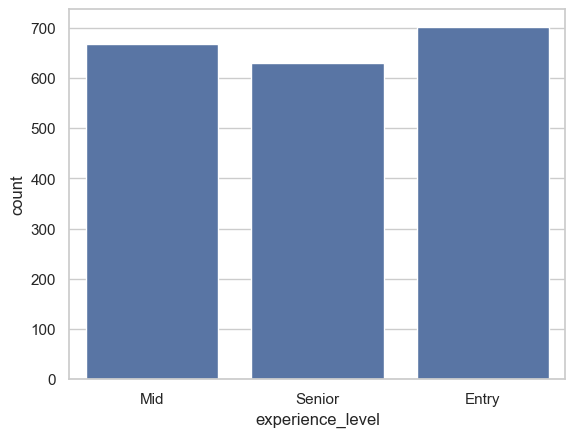

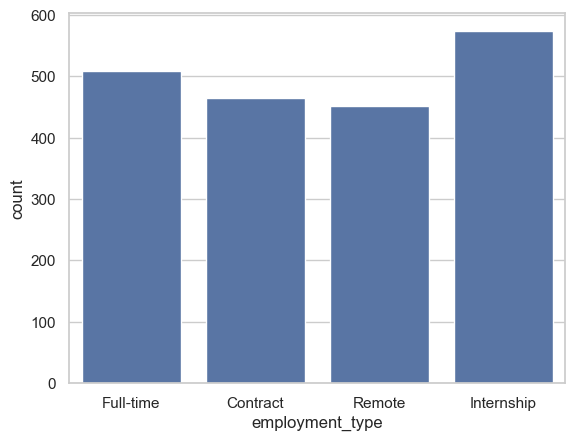

In [22]:
sns.countplot(x='experience_level', data=df)
plt.show()

sns.countplot(x='employment_type', data=df)
plt.show()

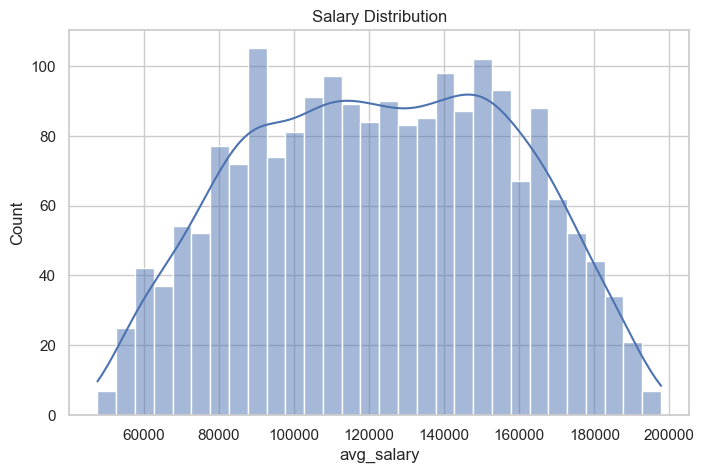

In [13]:
# Salary Distribution

plt.figure(figsize=(8,5))
sns.histplot(df['avg_salary'], bins=30, kde=True)
plt.title("Salary Distribution")
plt.show()

In [15]:
# Categorical Analysis

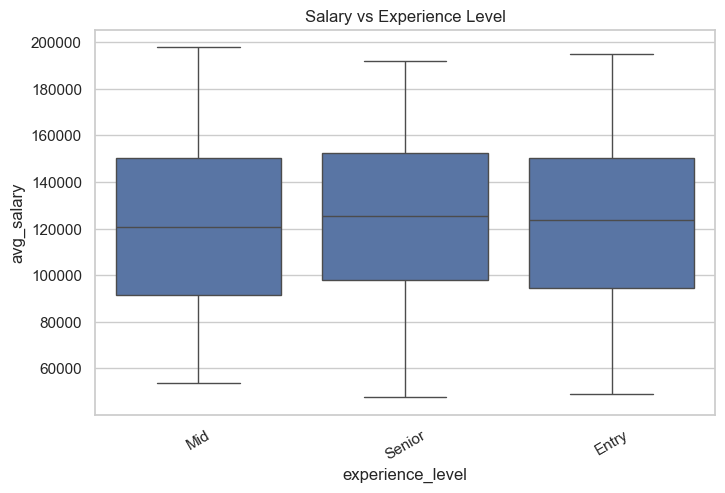

In [14]:
# Experience Level vs Salary

plt.figure(figsize=(8,5))
sns.boxplot(x='experience_level', y='avg_salary', data=df)
plt.title("Salary vs Experience Level")
plt.xticks(rotation=30)
plt.show()

In [ ]:
# Salary distribution appears similar across experience levels, suggesting the dataset may be simulated or lacks real-world salary progression patterns.

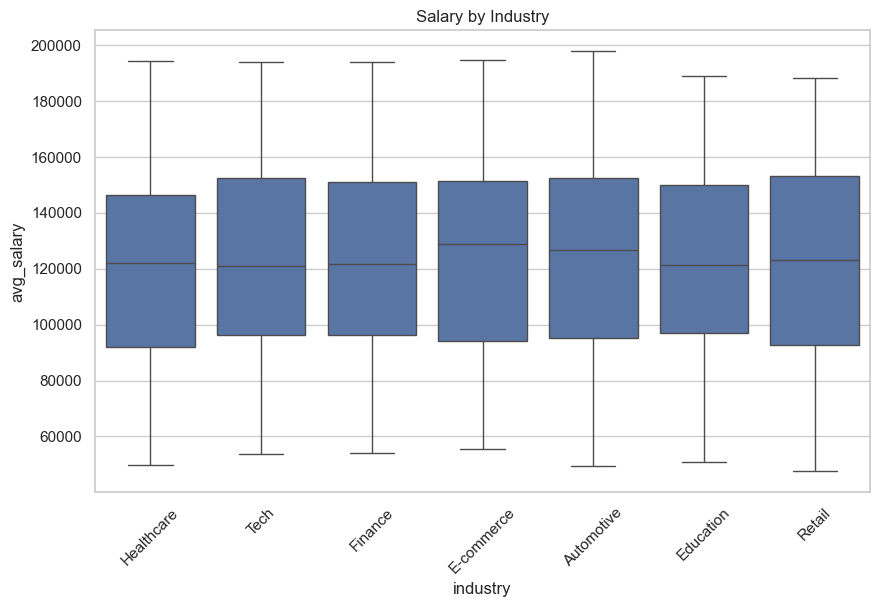

In [16]:
# Industry vs Salary

plt.figure(figsize=(10,6))
sns.boxplot(x='industry', y='avg_salary', data=df)
plt.title("Salary by Industry")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Salary variation across industries is minimal, indicating weak differentiation in pay structure across sectors in this dataset.

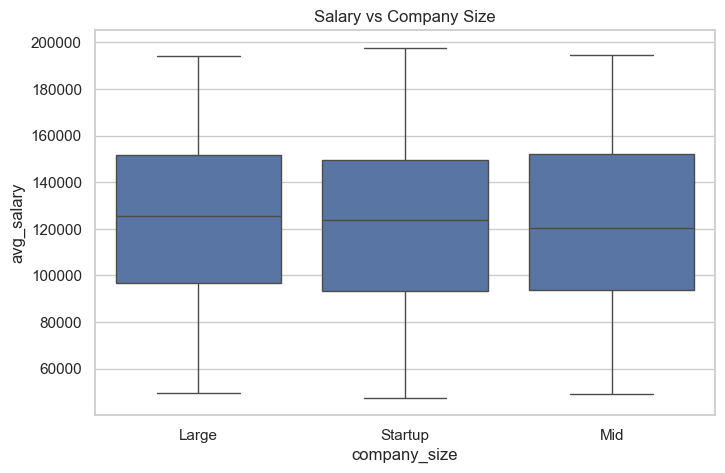

In [17]:
# Company Size vs Salary

plt.figure(figsize=(8,5))
sns.boxplot(x='company_size', y='avg_salary', data=df)
plt.title("Salary vs Company Size")
plt.show()

In [ ]:
# Company size does not significantly impact salary in this dataset.

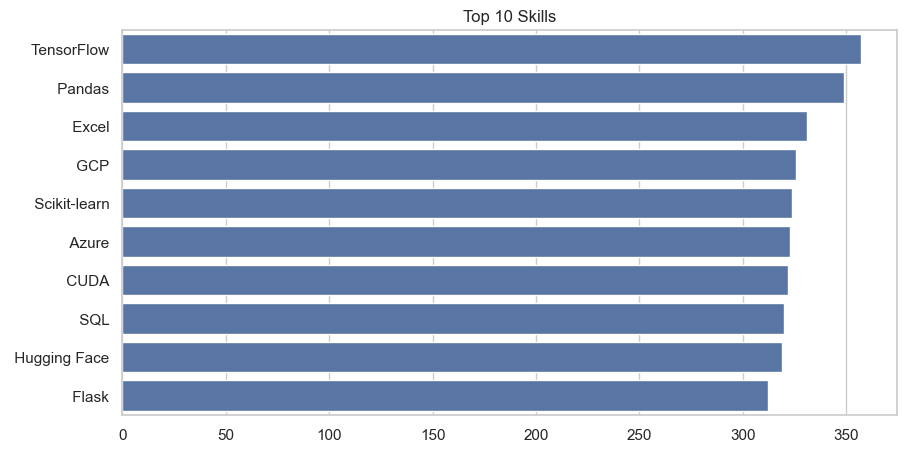

In [19]:
# Skill Analysis

from collections import Counter

all_skills = []

for skills in df['skills_required']:
    all_skills.extend(skills.split(','))

skill_counts = Counter(all_skills)

top_skills = dict(skill_counts.most_common(10))

plt.figure(figsize=(10,5))
sns.barplot(x=list(top_skills.values()), y=list(top_skills.keys()))
plt.title("Top 10 Skills")
plt.show()

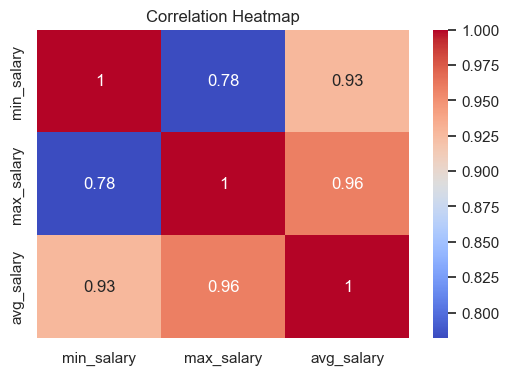

In [20]:
# Correlation 

numeric_df = df[['min_salary','max_salary','avg_salary']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()